In [18]:
import pandas as pd

def processingdata():
    df = pd.read_csv("healthcare-dataset-stroke-data.csv")  # Load the dataset
    dictn = {}  # To store encoding mappings for categorical columns
    cols = df.select_dtypes(include=["object"]).columns  # Identify categorical columns

    for col in df.columns:
        if col in cols:
            # Handle missing values in categorical columns using the mode
            df[col] = df[col].fillna(df[col].mode()[0])
            
            # Encode unique categorical values into integers
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            
            # Store the mapping for possible reverse conversion or analysis
            dictn[col] = mpp
        else:
            # Convert values to numeric and handle non-convertible entries as NaN
            df[col] = pd.to_numeric(df[col], errors="coerce")
            
            # Fill missing numeric values with the column mean
            df[col] = df[col].fillna(df[col].mean())
    
    return df, dictn

# Run the preprocessing and inspect results
df, dictn = processingdata()
print(df.head())     # View first few rows of processed data
print(dictn)         # View mappings used for categorical columns


      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0   9046       0  67.0             0              1             0          0   
1  51676       1  61.0             0              0             0          1   
2  31112       0  80.0             0              1             0          0   
3  60182       1  49.0             0              0             0          0   
4   1665       1  79.0             1              0             0          1   

   Residence_type  avg_glucose_level        bmi  smoking_status  stroke  
0               0             228.69  36.600000               0       1  
1               1             202.21  28.893237               1       1  
2               1             105.92  32.500000               1       1  
3               0             171.23  34.400000               2       1  
4               1             174.12  24.000000               1       1  
{'gender': {'Male': 0, 'Female': 1, 'Other': 2}, 'ever_married': {'Yes': 0,

Logistic Regression Before PCA

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('stroke', axis=1),  # Features
    df['stroke'],               # Target
    test_size=0.2,
    random_state=42
)

# Initialize a logistic regression model with balanced class weights to handle imbalance
model_1 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, solver='liblinear')
model_1.fit(X_train, y_train)  # Train the model on the training data

# Generate predictions for the test set
y_pred = model_1.predict(X_test)

# Evaluate the model's performance before applying PCA
print("Logistic Regression Before PCA")
print("Accuracy:", accuracy_score(y_test, y_pred))  # Basic accuracy score
print(classification_report(y_test, y_pred))        # Detailed performance metrics


Logistic Regression Before PCA
Accuracy: 0.7475538160469667
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       960
           1       0.16      0.76      0.27        62

    accuracy                           0.75      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.93      0.75      0.81      1022



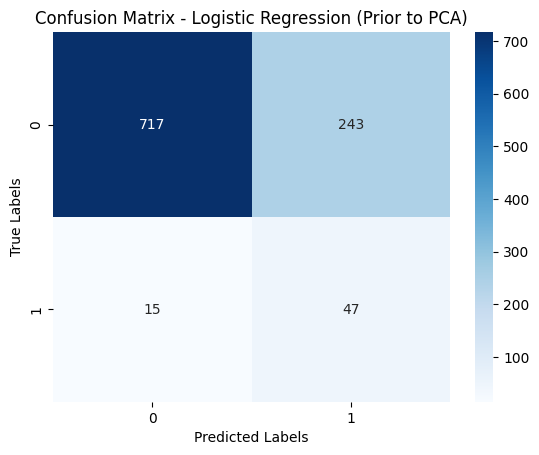

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix to assess classification performance
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap to visually represent the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add plot titles and labels for clarity
plt.title("Confusion Matrix - Logistic Regression (Prior to PCA)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


PCA Implementation

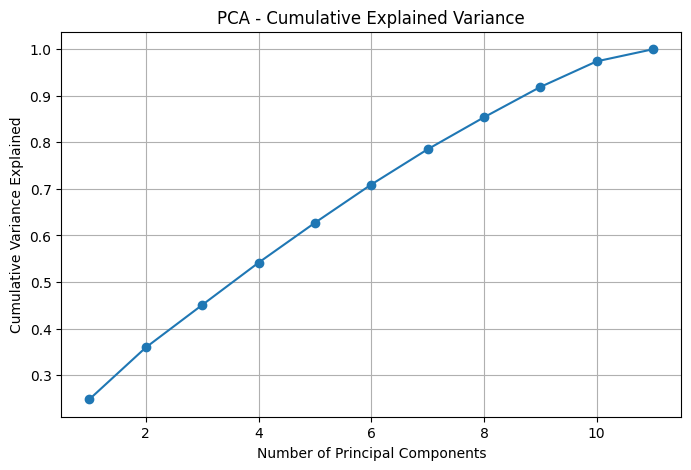

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Separate features and target variable
X = df.drop(columns=['stroke'])  # Features only
y = df['stroke']                 # Target labels

# Standardize the features to have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Principal Component Analysis (PCA) to the scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualize how much variance is retained as components increase
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1), 
    pca.explained_variance_ratio_.cumsum(), 
    marker='o'
)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [23]:
# Perform PCA with the number of components set to 9
pca_final = PCA(n_components=9)
X_pca_final = pca_final.fit_transform(X_scaled)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(9)])

# Reattach the target variable to the PCA-transformed DataFrame
pca_df['stroke'] = y.values

# Preview the resulting DataFrame
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,stroke
0,3.221169,3.283013,-1.537321,-0.297079,-1.297812,1.530022,1.783939,-0.945765,1.528919,1
1,1.245522,0.200973,1.128576,-0.067240,1.079238,0.309756,1.481981,-0.945867,-1.053727,1
2,2.426868,2.284803,0.573813,-0.461361,-2.074210,2.544963,-0.012649,0.580955,1.213932,1
3,1.108826,-0.366884,-0.254789,1.340682,0.859843,-0.172847,1.589078,0.337454,-0.355587,1
4,2.044716,1.247470,-0.160299,-2.110058,2.373079,-0.219169,-1.365524,-0.628045,-1.073827,1


Logistic Regression After PCA

In [15]:
# Logistic Regression on PCA-transformed features

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Split the reduced-dimension dataset into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    pca_df.drop('stroke', axis=1), 
    pca_df['stroke'], 
    test_size=0.2, 
    random_state=42
)

# Initialize and train a logistic regression model with balanced class weights
logreg_pca = LogisticRegression(class_weight='balanced')
logreg_pca.fit(X_pca_train, y_pca_train)

# Make predictions on the test set
y_pca_pred = logreg_pca.predict(X_pca_test)

# Evaluate performance using accuracy and a detailed classification report
print("Accuracy:", accuracy_score(y_pca_test, y_pca_pred))
print(classification_report(y_pca_test, y_pca_pred, target_names=["No Stroke", "Stroke"]))


Accuracy: 0.6976516634050881
              precision    recall  f1-score   support

   No Stroke       0.99      0.69      0.81       960
      Stroke       0.15      0.84      0.25        62

    accuracy                           0.70      1022
   macro avg       0.57      0.76      0.53      1022
weighted avg       0.93      0.70      0.78      1022



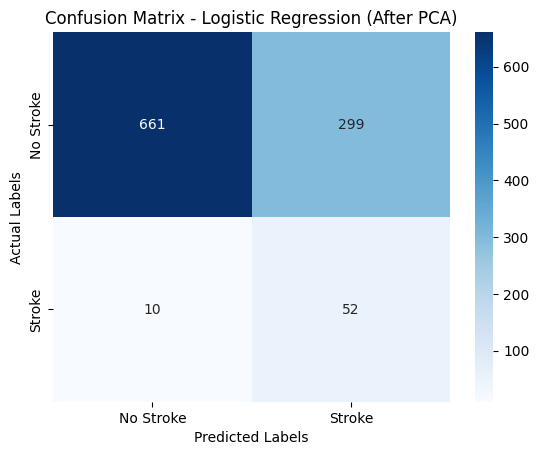

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for PCA-based predictions
conf_matrix_pca = confusion_matrix(y_pca_test, y_pca_pred)

# Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"])

# Add labels and title for better understanding
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix - Logistic Regression (After PCA)")
plt.show()